In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_perplexity import ChatPerplexity
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random
import os

In [5]:
## Loading the enviroment
load_dotenv()

True

In [6]:
## Defining and initiating model
# model = ChatPerplexity(model= 'sonar', api_key= os.getenv("PERPLEXITY_API_KEY"))

## Since perplexity models does not have the functionality to bind tools, therefore for tool creation we are using HuggingFace models
## Initializing HuggingFace LLM
llm = HuggingFaceEndpoint(
    repo_id= 'meta-llama/Llama-3.2-1B-Instruct'
)

## Initializing model
model = ChatHuggingFace(llm = llm)

c:\Users\DELL\Desktop\LangGraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Tools
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=WQX4A0SB195TCL5P"
    r = requests.get(url)
    return r.json()


In [8]:
# Make tool list
tools = [get_stock_price, search_tool, calculator]

# Make the LLM tool-aware
llm_with_tools = model.bind_tools(tools)

In [9]:
# Defining state
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [10]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [16]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [17]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", END)  

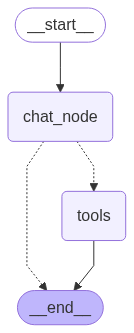

In [18]:
chatbot = graph.compile()

chatbot

In [19]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!, reply in one word")]})

print(out["messages"][-1].content)

BadRequestError: (Request ID: Root=1-68c1c489-4e99e778421f037503ff45b7;7d38f90f-47b6-4375-98a4-b64af806f7a6)

Bad request: